# Cross-Architecture Energy Prediction — Modelling

Predicts task **runtime, memory, and energy** and studies how well predictions transfer across architectures. Energy models are trained on both Augur clusters (gu + hu).

Two energy models are produced:
- **hardware-aware** (`models`) — includes hardware features; used for same/cross-architecture work
- **task-only** (`energy_model_task`) — no hardware features; used for cross-vendor laptop validation, where the laptop's benchmark scale is not comparable to the training clusters

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_percentage_error, median_absolute_error
from scipy.stats import spearmanr, pearsonr
df = pd.read_csv("../Processed_data/unified_data_new.csv")
df["task_type"] = df["process"].str.split(":").str[-1].str.upper()
print(df.shape)

(22672, 16)


### Sanity checks

In [2]:
print(df.groupby("source_dataset")[["runtime_s", "peak_mem", "energy_j"]].describe())
print("\n", df["task_type"].nunique(), "normalized task types")
print("zero runtime:", (df["runtime_s"]==0).sum(), " zero energy:", (df["energy_j"]==0).sum())

               runtime_s                                                      \
                   count           mean           std  min      25%      50%   
source_dataset                                                                 
augur_gu          1993.0  230485.904165  4.371731e+05  0.0  16000.0  85500.0   
augur_hu         11855.0  121240.052805  2.189949e+05  0.0   7500.0  36000.0   
lotaru            8824.0  309632.404238  1.065967e+06  8.0   8363.5  36069.5   

                                      peak_mem                ...  \
                      75%         max    count          mean  ...   
source_dataset                                                ...   
augur_gu        267000.00   5072000.0   1990.0  2.552580e+09  ...   
augur_hu        154000.00   8318207.0  11855.0  2.559022e+09  ...   
lotaru          191846.25  24154000.0   8824.0  1.680080e+09  ...   

                                           energy_j                \
                         75%       

## Phase 2 — Baseline models (both Augur clusters)

Trained on gu + hu pooled. Two feature sets: **task-only** (transfers across vendors) and **hardware-aware** (hardware features vary across the two clusters, so they are meaningful).

In [3]:
aug = df[df["source_dataset"].isin(["augur_gu", "augur_hu"])].copy()
aug_encoded = pd.get_dummies(aug, columns=["task_type"], prefix="task")
task_features = [c for c in aug_encoded.columns if c.startswith("task_")]

feats_task = ["rchar", "cpus", "concurrent_task_count"] + task_features
feats_hw   = ["rchar", "cpus", "concurrent_task_count",
              "cores", "ram", "cpu_benchmark", "io_read", "io_write"] + task_features

print(f"task-only model: {len(feats_task)} features")
print(f"hardware model:  {len(feats_hw)} features  ({len(task_features)} task types)")

task-only model: 101 features
hardware model:  106 features  (98 task types)


In [4]:
def evaluate_target(data, target, feature_cols):
    non_task = [c for c in feature_cols if not c.startswith("task_")]
    d = data.dropna(subset=[target] + non_task)
    d = d[d[target] > 0]
    X, y = d[feature_cols], d[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{target:12s} R2={r2_score(y_test,pred):.3f} "
          f"MAPE={mean_absolute_percentage_error(y_test,pred):.2f} "
          f"MedAE={median_absolute_error(y_test,pred):,.0f} (n={len(d)})")
    return model

# runtime + energy: both clusters (hardware variety helps)
models = {}
models["runtime_s"] = evaluate_target(aug_encoded, "runtime_s", feats_hw)
models["energy_j"]  = evaluate_target(aug_encoded, "energy_j",  feats_hw)
energy_model_task   = evaluate_target(aug_encoded, "energy_j",  feats_task)

# memory: single source only, to avoid cross-source calibration blur
hu = df[df["source_dataset"] == "augur_hu"].copy()
hu_encoded = pd.get_dummies(hu, columns=["task_type"], prefix="task")
hu_task_feats = [c for c in hu_encoded.columns if c.startswith("task_")]
feats_mem = ["rchar", "cpus", "concurrent_task_count"] + hu_task_feats
models["peak_mem"] = evaluate_target(hu_encoded, "peak_mem", feats_mem)

runtime_s    R2=0.702 MAPE=0.19 MedAE=3,114 (n=12468)
energy_j     R2=0.831 MAPE=0.17 MedAE=553 (n=12720)
energy_j     R2=0.830 MAPE=0.19 MedAE=634 (n=12720)
peak_mem     R2=0.984 MAPE=0.13 MedAE=1,649,787 (n=11855)


### Feature importance (hardware-aware energy model)

In [5]:
m = models["energy_j"]
importances = sorted(zip(feats_hw, m.feature_importances_), key=lambda x: -x[1])[:10]
for name, imp in importances:
    print(f"{name:35s} {imp:.3f}")

rchar                               0.535
task_MINIMAP2_ALIGN                 0.079
task_DEEPTOOLS_COMPUTEMATRIX        0.065
task_STAR_ALIGN_IGENOMES            0.064
task_QUALIMAP_RNASEQ                0.064
task_PICARD_MARKDUPLICATES          0.051
task_DEEPTOOLS_PLOTHEATMAP          0.022
task_BAMBU                          0.019
task_SALMON_INDEX                   0.014
task_DEEPTOOLS_PLOTFINGERPRINT      0.012


## Phase 4 — Cross-architecture transfer

Zero-shot: train on one cluster, test on the other. Hardware features included so the model can (attempt to) account for the different hardware.

In [6]:
base_features = ["rchar", "cpus", "cores", "ram", "cpu_benchmark", "io_read", "io_write"]

def cross_architecture_exp(df, train_source, test_source, target):
    d = df.dropna(subset=[target] + base_features).copy()
    d = d[d[target] > 0]
    d = pd.get_dummies(d, columns=["task_type"], prefix="task")
    task_cols = [c for c in d.columns if c.startswith("task_")]
    feats = base_features + task_cols
    train = d[d["source_dataset"].isin(train_source)]
    test  = d[d["source_dataset"] == test_source]
    Xtr, ytr = train[feats], train[target]
    Xte, yte = test.reindex(columns=feats, fill_value=0), test[target]
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    print(f"  {target:10s}  R2={r2_score(yte, pred):.3f}  MAPE={mean_absolute_percentage_error(yte, pred):.2f}")

print("Train augur_gu -> test augur_hu:")
for t in ["runtime_s", "peak_mem", "energy_j"]:
    cross_architecture_exp(df, ["augur_gu"], "augur_hu", t)
print("\nTrain augur_hu -> test augur_gu:")
for t in ["runtime_s", "peak_mem", "energy_j"]:
    cross_architecture_exp(df, ["augur_hu"], "augur_gu", t)

Train augur_gu -> test augur_hu:
  runtime_s   R2=-0.069  MAPE=2.42
  peak_mem    R2=0.950  MAPE=1.09
  energy_j    R2=0.694  MAPE=0.44

Train augur_hu -> test augur_gu:
  runtime_s   R2=0.603  MAPE=0.50
  peak_mem    R2=0.972  MAPE=0.33
  energy_j    R2=0.789  MAPE=0.38


### Runtime range check (diagnoses the zero-shot runtime asymmetry)

In [7]:
for src in ["augur_gu", "augur_hu"]:
    r = df[df["source_dataset"]==src]["runtime_s"]
    print(f"{src}: median={r.median():.0f}, max={r.max():.0f}, 95th={r.quantile(0.95):.0f}")

augur_gu: median=85500, max=5072000, 95th=870400
augur_hu: median=36000, max=8318207, 95th=526450


### Few-shot calibration curves
Add increasing fractions of target-cluster data to training; measure recovery.

In [8]:
def few_shot_collect(df, train_source, target_source, target, fractions=[0.0, 0.05, 0.10, 0.20, 0.50]):
    d = df.dropna(subset=[target] + base_features).copy()
    d = d[d[target] > 0]
    d = pd.get_dummies(d, columns=["task_type"], prefix="task")
    task_cols = [c for c in d.columns if c.startswith("task_")]
    feats = base_features + task_cols
    src = d[d["source_dataset"] == train_source]
    tgt = d[d["source_dataset"] == target_source].sample(frac=1.0, random_state=42)
    rows = []
    for frac in fractions:
        n_cal = int(len(tgt) * frac)
        train = pd.concat([src, tgt.iloc[:n_cal]], ignore_index=True)
        test = tgt.iloc[n_cal:]
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        model.fit(train[feats], train[target])
        pred = model.predict(test.reindex(columns=feats, fill_value=0))
        rows.append({"train": train_source, "test": target_source, "target": target,
                     "target_fraction": frac, "r2": r2_score(test[target], pred),
                     "n_train": len(train), "n_test": len(test)})
    return rows

all_results = []
for (train_s, test_s) in [("augur_gu", "augur_hu"), ("augur_hu", "augur_gu")]:
    for target in ["runtime_s", "peak_mem", "energy_j"]:
        all_results.extend(few_shot_collect(df, train_s, test_s, target))

results_df = pd.DataFrame(all_results)
results_df.to_csv("../Processed_data/cross_arch_fewshot_results.csv", index=False)
print("Saved", len(results_df), "rows")
results_df

Saved 30 rows


,train,test,target,target_fraction,r2,n_train,n_test
0,augur_gu,augur_hu,runtime_s,0.00,-0.068695,1862,10606
1,augur_gu,augur_hu,runtime_s,0.05,0.768704,2392,10076
2,augur_gu,augur_hu,runtime_s,0.10,0.775184,2922,9546
3,augur_gu,augur_hu,runtime_s,0.20,0.786140,3983,8485
4,augur_gu,augur_hu,runtime_s,0.50,0.704287,7165,5303
5,augur_gu,augur_hu,peak_mem,0.00,0.950080,1988,11855
6,augur_gu,augur_hu,peak_mem,0.05,0.988795,2580,11263
7,augur_gu,augur_hu,peak_mem,0.10,0.991325,3173,10670
8,augur_gu,augur_hu,peak_mem,0.20,0.991585,4359,9484
9,augur_gu,augur_hu,peak_mem,0.50,0.995147,7915,5928


### Data-cost curve figure

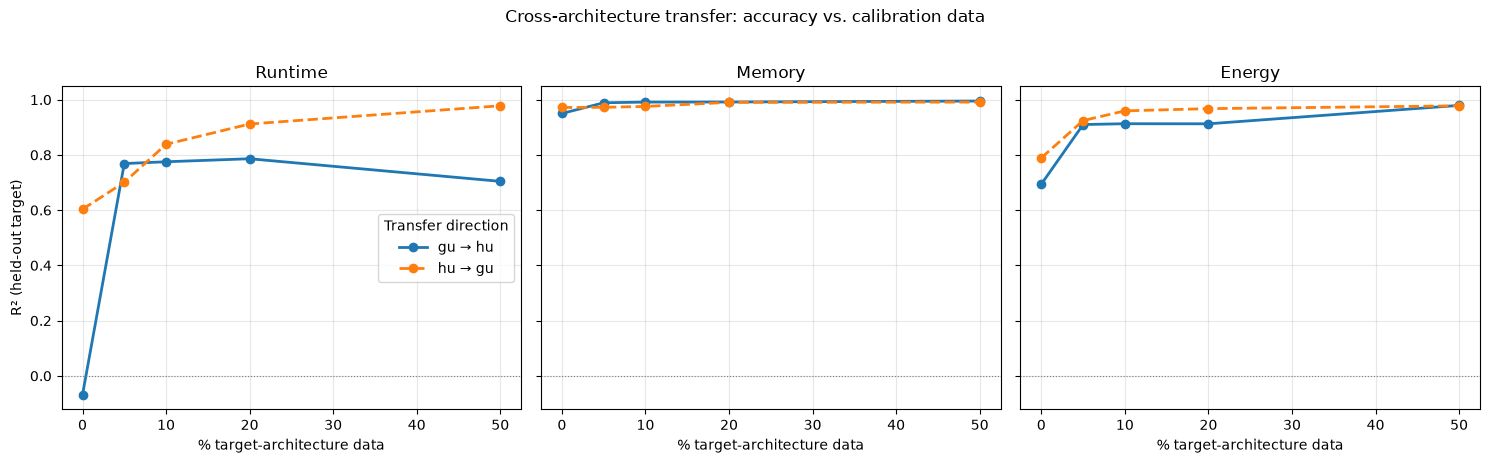

In [9]:
metrics = results_df["target"].unique().tolist()
titles = dict(zip(metrics, ["Runtime", "Memory", "Energy"]))
directions = [("augur_gu", "augur_hu"), ("augur_hu", "augur_gu")]
dir_style = {("augur_gu", "augur_hu"): ("-", "gu \u2192 hu"),
             ("augur_hu", "augur_gu"): ("--", "hu \u2192 gu")}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, metric in zip(axes, metrics):
    for (train_s, test_s) in directions:
        sub = results_df[(results_df["target"]==metric) & (results_df["train"]==train_s) &
                         (results_df["test"]==test_s)].sort_values("target_fraction")
        style, label = dir_style[(train_s, test_s)]
        ax.plot(sub["target_fraction"]*100, sub["r2"], style, marker="o", label=label, linewidth=2)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(titles[metric]); ax.set_xlabel("% target-architecture data"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("R\u00b2 (held-out target)")
axes[0].legend(title="Transfer direction")
fig.suptitle("Cross-architecture transfer: accuracy vs. calibration data", y=1.02)
plt.tight_layout()
plt.savefig("../Processed_data/data_cost_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### Eight-architecture transfer matrix
gu and hu each count as one architecture (identical nodes within a cluster); Lotaru contributes six.

In [10]:
def get_architecture(row):
    if row["source_dataset"] == "lotaru":
        return f"lot_{row['node']}"
    elif row["source_dataset"] == "augur_gu":
        return "gu"
    return "hu"

df["architecture"] = df.apply(get_architecture, axis=1)
print(df["architecture"].value_counts())

architecture
hu           11855
gu            1993
lot_a1        1501
lot_a2        1501
lot_c2        1501
lot_n2        1501
lot_n1        1487
lot_local     1333
Name: count, dtype: int64


Runtime transfer matrix:
test         gu     hu  lot_a1  lot_a2  lot_c2  lot_local  lot_n1  lot_n2
train                                                                    
gu         0.99  -0.07    0.07    0.07    0.19       0.19    0.12    0.18
hu         0.60   0.99    0.07    0.07    0.20       0.18    0.13    0.18
lot_a1    -1.65 -76.30    0.99    0.99   -0.18       0.53    0.71    0.20
lot_a2    -1.45 -74.08    0.98    0.99   -0.12       0.56    0.73    0.24
lot_c2    -0.23 -31.92    0.62    0.62    0.98       0.88    0.85    0.96
lot_local -0.32  -3.37    0.67    0.67    0.78       0.99    0.73    0.80
lot_n1    -0.32 -84.95    0.77    0.78    0.85       0.96    0.99    0.93
lot_n2    -0.29 -36.90    0.67    0.67    0.98       0.92    0.89    0.98


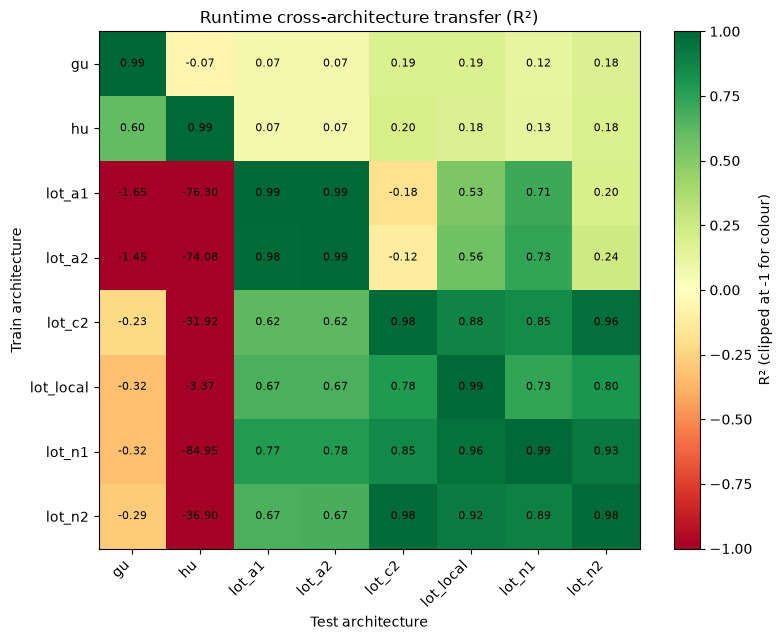

In [11]:
def transfer_matrix(df, target, architectures):
    d = df.dropna(subset=[target] + base_features).copy()
    d = d[d[target] > 0]
    d = pd.get_dummies(d, columns=["task_type"], prefix="task")
    task_cols = [c for c in d.columns if c.startswith("task_")]
    feats = base_features + task_cols
    rows = []
    for train_arch in architectures:
        tr = d[d["architecture"] == train_arch]
        if len(tr) < 30: continue
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        model.fit(tr[feats], tr[target])
        for test_arch in architectures:
            te = d[d["architecture"] == test_arch]
            if len(te) < 30: continue
            pred = model.predict(te.reindex(columns=feats, fill_value=0))
            rows.append({"train": train_arch, "test": test_arch, "r2": r2_score(te[target], pred)})
    return pd.DataFrame(rows)

def plot_heatmap(pivot, title, path):
    clipped = pivot.clip(lower=-1)
    fig, ax = plt.subplots(figsize=(8, 6.5))
    im = ax.imshow(clipped.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(clipped.columns))); ax.set_yticks(range(len(clipped.index)))
    ax.set_xticklabels(clipped.columns, rotation=45, ha="right"); ax.set_yticklabels(clipped.index)
    ax.set_xlabel("Test architecture"); ax.set_ylabel("Train architecture"); ax.set_title(title)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
    fig.colorbar(im, ax=ax, label="R\u00b2 (clipped at -1 for colour)")
    plt.tight_layout(); plt.savefig(path, dpi=150, bbox_inches="tight"); plt.show()

architectures = df["architecture"].unique().tolist()
rt_pivot = transfer_matrix(df, "runtime_s", architectures).pivot(index="train", columns="test", values="r2")
print("Runtime transfer matrix:"); print(rt_pivot.round(2))
plot_heatmap(rt_pivot, "Runtime cross-architecture transfer (R\u00b2)", "../Processed_data/runtime_heatmap.png")

Memory transfer matrix:
test         gu    hu  lot_a1  lot_a2  lot_c2  lot_local  lot_n1  lot_n2
train                                                                   
gu         1.00  0.95    0.06    0.06    0.06       0.07    0.07    0.05
hu         0.97  1.00    0.04    0.04    0.04       0.05    0.04    0.03
lot_a1     0.00  0.04    1.00    0.99    0.99       0.98    0.99    0.98
lot_a2    -0.00  0.03    0.99    1.00    0.99       0.98    0.99    0.98
lot_c2    -0.00  0.03    0.99    0.99    1.00       0.98    0.99    0.99
lot_local  0.01  0.05    0.98    0.98    0.98       1.00    0.98    0.99
lot_n1    -0.00  0.03    0.99    0.99    0.99       0.99    1.00    0.99
lot_n2    -0.00  0.04    0.98    0.98    0.99       1.00    0.99    1.00


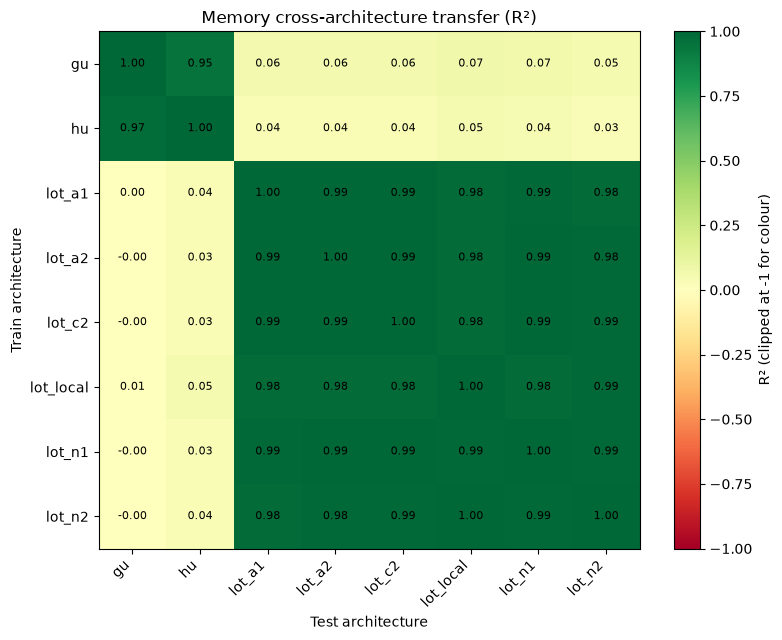

In [12]:
mem_pivot = transfer_matrix(df, "peak_mem", architectures).pivot(index="train", columns="test", values="r2")
print("Memory transfer matrix:"); print(mem_pivot.round(2))
plot_heatmap(mem_pivot, "Memory cross-architecture transfer (R\u00b2)", "../Processed_data/peak_mem_heatmap.png")

Diagnostic: why cross-source memory transfer fails (task-type memory calibration differs).

In [13]:
for src in ["augur_hu", "lotaru"]:
    sub = df[(df["source_dataset"]==src) & (df["peak_mem"]>0)]
    print(src, "rchar-memory corr:", round(sub["rchar"].corr(sub["peak_mem"]), 3),
          "| median mem:", f"{sub['peak_mem'].median():.2e}",
          "| median rchar:", f"{sub['rchar'].median():.2e}")

augur_hu rchar-memory corr: 0.148 | median mem: 3.61e+07 | median rchar: 1.25e+09
lotaru rchar-memory corr: 0.123 | median mem: 5.69e+08 | median rchar: 9.05e+08


## Cross-vendor validation (AMD Ryzen laptop)

Uses the **task-only** energy model, because the laptop's benchmark scale is not comparable to the training clusters. Validates whether task-level energy relationships transfer across CPU vendors.

### atacseq — per-task validation (parsed input sizes)

In [14]:
import re
def parse_size(s):
    if pd.isna(s): return np.nan
    m = re.match(r"([\d.]+)\s*([KMGT]?B)", str(s).strip())
    if not m: return np.nan
    mult = {"B":1, "KB":1e3, "MB":1e6, "GB":1e9, "TB":1e12}[m.group(2)]
    return float(m.group(1)) * mult

lap = pd.read_csv("../Processed_data/laptop_measured_energy.csv")
lap["rchar"] = lap["rchar"].apply(parse_size)
lap["measured_energy_j"] = pd.to_numeric(lap["measured_energy_j"], errors="coerce")
lap = lap.dropna(subset=["rchar", "measured_energy_j"])
lap = lap[lap["measured_energy_j"] > 0]
lap["cpus"] = 1
lap["concurrent_task_count"] = 0
lap_enc = pd.get_dummies(lap, columns=["task_type"], prefix="task")

X_lap = lap_enc.reindex(columns=energy_model_task.feature_names_in_, fill_value=0)
lap["predicted_energy_j"] = energy_model_task.predict(X_lap)

rho, p = spearmanr(lap["measured_energy_j"], lap["predicted_energy_j"])
print(f"atacseq per-task validation (n={len(lap)}):")
print(f"  Spearman: {rho:.3f}  (p={p:.4f})")
mask = (lap["measured_energy_j"]>0) & (lap["predicted_energy_j"]>0)
r_log, _ = pearsonr(np.log(lap.loc[mask,"measured_energy_j"]), np.log(lap.loc[mask,"predicted_energy_j"]))
print(f"  Pearson (log-log): {r_log:.3f}")
lap.to_csv("../Processed_data/laptop_validation_final.csv", index=False)

atacseq per-task validation (n=220):
  Spearman: 0.712  (p=0.0000)
  Pearson (log-log): 0.586


### chipseq — per-task validation across all three targets

In [15]:
lap_chipseq = pd.read_csv("../Processed_data/chipseq_laptop_measured.csv")
lap_chipseq = lap_chipseq.dropna(subset=["measured_energy_j"])
lap_chipseq = lap_chipseq[lap_chipseq["measured_energy_j"] > 0]
lap_chipseq["concurrent_task_count"] = 0
lap_enc = pd.get_dummies(lap_chipseq, columns=["task_type"], prefix="task")

# energy via task-only model
X = lap_enc.reindex(columns=energy_model_task.feature_names_in_, fill_value=0)
lap_chipseq["predicted_energy_j"] = energy_model_task.predict(X)
rho, p = spearmanr(lap_chipseq["measured_energy_j"], lap_chipseq["predicted_energy_j"])
print(f"chipseq ENERGY  (n={len(lap_chipseq)}): Spearman {rho:.3f} (p={p:.4g})")

lap_chipseq.to_csv("../Processed_data/chipseq_predictions_vs_actual_new.csv", index=False)

chipseq ENERGY  (n=190): Spearman 0.739 (p=3.906e-34)


### Runtime and memory validation (hardware-aware models)
Runtime uses `realtime`; memory uses `peak_rss`. Tasks with zero runtime are dropped.

In [16]:
def validate(target_col, model_key, label):
    m = models[model_key]
    X = lap_enc.reindex(columns=m.feature_names_in_, fill_value=0)
    pred = m.predict(X)
    v = pd.DataFrame({"measured": lap_chipseq[target_col].values, "predicted": pred})
    v = v[(v["measured"] > 0) & (v["predicted"] > 0)].dropna()
    rho, p = spearmanr(v["measured"], v["predicted"])
    ratio = (v["predicted"] / v["measured"]).median()
    print(f"{label:16s} (n={len(v)}): Spearman {rho:.3f} (p={p:.3g}) | median pred/meas {ratio:.2f}x")
    return v

validate("realtime", "runtime_s", "RUNTIME (ms)")
validate("peak_rss", "peak_mem",  "MEMORY (bytes)")


RUNTIME (ms)     (n=122): Spearman 0.693 (p=9.2e-19) | median pred/meas 1.83x
MEMORY (bytes)   (n=189): Spearman 0.644 (p=1.51e-23) | median pred/meas 0.93x


,measured,predicted
0,8937472,2.922189e+06
1,6553600,3.154125e+06
2,10493952,3.156756e+06
3,133464064,2.882723e+07
4,8790016,1.571530e+09
...,...,...
185,112283648,7.516468e+08
186,331837440,1.622429e+09
187,332234752,1.622429e+09
188,173113344,7.516468e+08


### Energy calibration (few-shot on target hardware)
A single scale factor from 10% of laptop tasks corrects the absolute magnitude.

In [17]:
d = pd.read_csv("../Processed_data/chipseq_predictions_vs_actual.csv")
d = d.dropna(subset=["measured_energy_j", "predicted_energy_j"])
d = d[(d["measured_energy_j"] > 0) & (d["predicted_energy_j"] > 0)]
calib = d.sample(frac=0.1, random_state=42)
scale = (calib["measured_energy_j"] / calib["predicted_energy_j"]).median()
rest = d.drop(calib.index).copy()
rest["predicted_calibrated"] = rest["predicted_energy_j"] * scale
print(f"Calibration factor: {scale:.3f}  (model over-predicts ~{1/scale:.1f}x)")
print(f"MAPE before: {mean_absolute_percentage_error(rest['measured_energy_j'], rest['predicted_energy_j']):.2f}")
print(f"MAPE after:  {mean_absolute_percentage_error(rest['measured_energy_j'], rest['predicted_calibrated']):.2f}")

Calibration factor: 0.177  (model over-predicts ~5.7x)
MAPE before: 10.30
MAPE after:  1.27


## Cross-vendor validation (Intel i5 laptop)

Same cross-vendor procedure as the Ryzen laptops, but on the Intel i5 (measured with RAPL rather than uProf). Reconstruct measured energy from the RAPL counter, predict with the task-only model, and calibrate.

### Build measured energy from the Intel RAPL log

In [41]:
import pandas as pd
import numpy as np

# --- Stage 1: build measured energy ---
rapl = pd.read_csv("../AhmedLaptopdata/chipseq_rapl.csv", header=None, names=["ts_ms","energy_uj"])
rapl = rapl.sort_values("ts_ms").reset_index(drop=True)
rapl["energy_diff_uj"] = rapl["energy_uj"].diff()
  # from the Intel machine!

# Intel machine max_energy_range_uj
# (from: cat /sys/class/powercap/intel-rapl:0/max_energy_range_uj)
RAPL_MAX_UJ = 262143328850

rapl.loc[rapl["energy_diff_uj"] < 0, "energy_diff_uj"] += RAPL_MAX_UJ
rapl["energy_j"] = rapl["energy_diff_uj"] / 1_000_000
rapl = rapl.dropna(subset=["energy_j"])

tr = pd.read_csv("../AhmedLaptopdata/chipseq_trace.csv")
tr = tr[tr["status"] == "COMPLETED"].copy()
tr["start"] = pd.to_numeric(tr["start"], errors="coerce")      # <-- must be numeric
tr["complete"] = pd.to_numeric(tr["complete"], errors="coerce")

def measured(s, c):
    m = (rapl["ts_ms"] >= s) & (rapl["ts_ms"] <= c)
    return rapl.loc[m, "energy_j"].sum()

tr["measured_energy_j"] = tr.apply(lambda r: measured(r["start"], r["complete"]), axis=1)
tr["task_type"] = tr["process"].str.split(":").str[-1].str.upper()
tr["concurrent_task_count"] = 0

# keep tasks with real energy (drops the 34 sub-second ones)
tr = tr[tr["measured_energy_j"] > 0].copy()
print(f"Tasks with measured energy: {len(tr)}")   # should be ~176

Tasks with measured energy: 176


### Predict energy (task-only model) and compare to measured

In [42]:
from scipy.stats import spearmanr
import numpy as np

# One-hot encode task_type to match training features
enc = pd.get_dummies(tr, columns=["task_type"], prefix="task")

# Predict energy using the TASK-ONLY model (cross-vendor: no hardware features)
X = enc.reindex(columns=energy_model.feature_names_in_, fill_value=0)
tr["predicted_energy_j"] = energy_model.predict(X)

# Compare predicted vs measured
v = tr[(tr["measured_energy_j"] > 0) & (tr["predicted_energy_j"] > 0)]
rho = spearmanr(v["measured_energy_j"], v["predicted_energy_j"]).correlation
ratio = (v["predicted_energy_j"] / v["measured_energy_j"]).median()
mape = np.mean(np.abs((v["predicted_energy_j"] - v["measured_energy_j"]) / v["measured_energy_j"])) * 100

print(f"Intel machine — Energy prediction(Chipseq Workflow):")
print(f"  n tasks:      {len(v)}")
print(f"  Spearman:     {rho:.3f}")
print(f"  Median ratio: {ratio:.2f}x (predicted/measured)")
print(f"  MAPE:         {mape:.1f}%")

# Save
tr.to_csv("../Processed_data/intel_chipseq_predictions_vs_actual.csv", index=False)

Intel machine — Energy prediction(Chipseq Workflow):
  n tasks:      176
  Spearman:     0.723
  Median ratio: 4.46x (predicted/measured)
  MAPE:         740.1%


### Load saved Intel predictions

In [43]:
intel_chipseq_preds = pd.read_csv("../Processed_data/intel_chipseq_predictions_vs_actual.csv")

intel_chipseq_preds.head()

,task_id,hostname,native_id,process,tag,name,status,exit,module,container,...,vol_ctxt,inv_ctxt,workdir,scratch,error_action,cpu_model,measured_energy_j,task_type,concurrent_task_count,predicted_energy_j
0,5,-,242594,NFCORE_CHIPSEQ:CHIPSEQ:INPUT_CHECK:SAMPLESHEET...,samplesheet_test.csv,NFCORE_CHIPSEQ:CHIPSEQ:INPUT_CHECK:SAMPLESHEET...,COMPLETED,0,-,quay.io/biocontainers/python:3.8.3,...,1,0,/home/ahmed/pranay/work/e5/a48f836d768a0f818b5...,-,-,12th Gen Intel(R) Core(TM) i5-12400,33.444861,SAMPLESHEET_CHECK,0,112.335527
1,4,-,242852,NFCORE_CHIPSEQ:CHIPSEQ:PREPARE_GENOME:CUSTOM_G...,genome.fa,NFCORE_CHIPSEQ:CHIPSEQ:PREPARE_GENOME:CUSTOM_G...,COMPLETED,0,-,quay.io/biocontainers/samtools:1.15.1--h1170115_0,...,1,0,/home/ahmed/pranay/work/c6/d982e6413c87880a0f7...,-,-,12th Gen Intel(R) Core(TM) i5-12400,9.604651,CUSTOM_GETCHROMSIZES,0,246.623210
2,1,-,242823,NFCORE_CHIPSEQ:CHIPSEQ:KHMER_UNIQUEKMERS,genome.fa,NFCORE_CHIPSEQ:CHIPSEQ:KHMER_UNIQUEKMERS (geno...,COMPLETED,0,-,quay.io/biocontainers/khmer:3.0.0a3--py37haa76...,...,16,0,/home/ahmed/pranay/work/a6/20453e907082c250297...,-,-,12th Gen Intel(R) Core(TM) i5-12400,35.694611,KHMER_UNIQUEKMERS,0,268.983734
3,3,-,242920,NFCORE_CHIPSEQ:CHIPSEQ:PREPARE_GENOME:GTF2BED,genes.gtf,NFCORE_CHIPSEQ:CHIPSEQ:PREPARE_GENOME:GTF2BED ...,COMPLETED,0,-,quay.io/biocontainers/perl:5.26.2,...,5,1,/home/ahmed/pranay/work/02/413c9fbe52ff9ddaa7a...,-,-,12th Gen Intel(R) Core(TM) i5-12400,35.694611,GTF2BED,0,246.623210
4,8,-,243569,NFCORE_CHIPSEQ:CHIPSEQ:PREPARE_GENOME:GENOME_B...,genome.fa.sizes,NFCORE_CHIPSEQ:CHIPSEQ:PREPARE_GENOME:GENOME_B...,COMPLETED,0,-,quay.io/biocontainers/bedtools:2.30.0--hc088bd4_0,...,2,0,/home/ahmed/pranay/work/ce/7f0bc438aee27902f43...,-,-,12th Gen Intel(R) Core(TM) i5-12400,26.089960,GENOME_BLACKLIST_REGIONS,0,224.706523


### Energy calibration — before/after (Intel i5)

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_percentage_error

# Load the Intel chipseq predictions you already generated
d = pd.read_csv("../Processed_data/intel_chipseq_predictions_vs_actual.csv")
d = d.dropna(subset=["measured_energy_j", "predicted_energy_j"])
d = d[(d["measured_energy_j"] > 0) & (d["predicted_energy_j"] > 0)].reset_index(drop=True)
print(f"Total tasks: {len(d)}")

# --- BEFORE calibration ---
def medape(meas, pred):
    return np.median(np.abs((pred - meas) / meas)) * 100

meas = d["measured_energy_j"].values
pred = d["predicted_energy_j"].values

print("\n=== BEFORE calibration ===")
print(f"  Median ratio: {np.median(pred/meas):.2f}x")
print(f"  MedAPE:       {medape(meas, pred):.1f}%")
print(f"  Spearman:     {spearmanr(meas, pred).correlation:.3f}")

# --- Derive scale factor from 10% held-out, apply to the other 90% ---
calib = d.sample(frac=0.10, random_state=42)
rest = d.drop(calib.index)

# scale factor = median of measured/predicted on the calibration sample
scale = (calib["measured_energy_j"] / calib["predicted_energy_j"]).median()
print(f"\nCalibration factor (from {len(calib)} tasks): {scale:.3f}")

# Apply to the held-out rest
rest = rest.copy()
rest["predicted_calibrated"] = rest["predicted_energy_j"] * scale

meas_r = rest["measured_energy_j"].values
pred_r = rest["predicted_energy_j"].values
pred_c = rest["predicted_calibrated"].values

print("\n=== AFTER calibration (on held-out 90%) ===")
print(f"  Median ratio: {np.median(pred_c/meas_r):.2f}x   (was {np.median(pred_r/meas_r):.2f}x)")
print(f"  MedAPE:       {medape(meas_r, pred_c):.1f}%   (was {medape(meas_r, pred_r):.1f}%)")
print(f"  MAPE:         {mean_absolute_percentage_error(meas_r, pred_c)*100:.1f}%   (was {mean_absolute_percentage_error(meas_r, pred_r)*100:.1f}%)")
print(f"  Spearman:     {spearmanr(meas_r, pred_c).correlation:.3f}   (unchanged by scaling)")

Total tasks: 176

=== BEFORE calibration ===
  Median ratio: 4.46x
  MedAPE:       345.6%
  Spearman:     0.723

Calibration factor (from 18 tasks): 0.288

=== AFTER calibration (on held-out 90%) ===
  Median ratio: 1.31x   (was 4.53x)
  MedAPE:       61.4%   (was 353.4%)
  MAPE:         176.2%   (was 769.5%)
  Spearman:     0.730   (unchanged by scaling)


In [46]:
import pandas as pd
import numpy as np

def add_calibration_column(filepath, sample_frac=0.10, seed=42):
    """Compute calibration factor from a sample, apply to all predictions,
    and save the calibrated values as a new column in the same file."""
    d = pd.read_csv(filepath)

    # Only calibrate rows with valid measured + predicted energy
    valid = d.dropna(subset=["measured_energy_j", "predicted_energy_j"])
    valid = valid[(valid["measured_energy_j"] > 0) & (valid["predicted_energy_j"] > 0)]

    # Derive the calibration factor from a 10% sample
    calib = valid.sample(frac=sample_frac, random_state=seed)
    factor = (calib["measured_energy_j"] / calib["predicted_energy_j"]).median()
    print(f"{filepath}")
    print(f"  Calibration factor: {factor:.4f}  (from {len(calib)} tasks)")

    # Apply the factor to ALL predicted values -> new column
    d["predicted_energy_j_calibrated"] = d["predicted_energy_j"] * factor

    # Save back to the same file (now with the extra column)
    d.to_csv(filepath, index=False)
    print(f"  Saved with new column 'predicted_energy_j_calibrated'\n")
    return factor

# Apply to both machines
add_calibration_column("../Processed_data/intel_chipseq_predictions_vs_actual.csv")
add_calibration_column("../Processed_data/chipseq_predictions_vs_actual_new.csv")

../Processed_data/intel_chipseq_predictions_vs_actual.csv
  Calibration factor: 0.2880  (from 18 tasks)
  Saved with new column 'predicted_energy_j_calibrated'

../Processed_data/chipseq_predictions_vs_actual_new.csv
  Calibration factor: 0.1766  (from 19 tasks)
  Saved with new column 'predicted_energy_j_calibrated'



np.float64(0.17659949660746088)

## Comparison with Augur's analytical scaling

Three approaches to cross-architecture prediction: learned zero-shot, Augur's benchmark-ratio scaling (no target data), and few-shot calibration. Demonstrates that a single hardware scaling factor cannot serve metrics with different hardware dependence, whereas few-shot does.

In [18]:
def arch_spec(dfsub):
    return dfsub[["cores", "cpu_benchmark", "io_write"]].median()

gu_spec = arch_spec(df[df["source_dataset"]=="augur_gu"])
hu_spec = arch_spec(df[df["source_dataset"]=="augur_hu"])

def augur_factor(local, target):
    r_cpu = local["cpu_benchmark"] / target["cpu_benchmark"]
    r_mem = local["io_write"] / target["io_write"]
    if local["cores"] != target["cores"]:
        return 0.7*r_cpu + 0.3*r_mem
    return 0.5*r_cpu + 0.5*r_mem

def compare_all(df, train_src, test_src, src_spec, tgt_spec, target, fractions=[0.05, 0.10, 0.20]):
    d = df.dropna(subset=[target, "rchar", "cpus"]).copy()
    d = d[d[target] > 0]
    d = pd.get_dummies(d, columns=["task_type"], prefix="task")
    task_cols = [c for c in d.columns if c.startswith("task_")]
    feats = ["rchar", "cpus", "concurrent_task_count"] + task_cols
    tr = d[d["source_dataset"]==train_src]
    te_all = d[d["source_dataset"]==test_src].sample(frac=1.0, random_state=42)
    m = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    m.fit(tr[feats].fillna(0), tr[target])
    Xte_all = te_all[feats].reindex(columns=feats, fill_value=0).fillna(0)
    r2_raw = r2_score(te_all[target], m.predict(Xte_all))
    f = augur_factor(src_spec, tgt_spec)
    r2_scaled = r2_score(te_all[target], m.predict(Xte_all) * f)
    fewshot_r2 = {}
    for frac in fractions:
        n_cal = int(len(te_all) * frac)
        cal, test = te_all.iloc[:n_cal], te_all.iloc[n_cal:]
        train = pd.concat([tr, cal], ignore_index=True)
        mf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        mf.fit(train[feats].fillna(0), train[target])
        Xtest = test[feats].reindex(columns=feats, fill_value=0).fillna(0)
        fewshot_r2[frac] = r2_score(test[target], mf.predict(Xtest))
    fs = "  ".join([f"{int(k*100)}%={v:.3f}" for k, v in fewshot_r2.items()])
    print(f"  {target:10s} | zero-shot={r2_raw:6.3f} | Augur(f={f:.2f})={r2_scaled:6.3f} | few-shot: {fs}")

print("gu -> hu:")
for t in ["runtime_s", "peak_mem", "energy_j"]:
    compare_all(df, "augur_gu", "augur_hu", gu_spec, hu_spec, t)
print("\nhu -> gu:")
for t in ["runtime_s", "peak_mem", "energy_j"]:
    compare_all(df, "augur_hu", "augur_gu", hu_spec, gu_spec, t)

gu -> hu:


  runtime_s  | zero-shot=-0.214 | Augur(f=0.23)= 0.383 | few-shot: 5%=0.744  10%=0.757  20%=0.773
  peak_mem   | zero-shot= 0.950 | Augur(f=0.23)= 0.274 | few-shot: 5%=0.989  10%=0.993  20%=0.994
  energy_j   | zero-shot= 0.685 | Augur(f=0.23)= 0.180 | few-shot: 5%=0.906  10%=0.907  20%=0.908

hu -> gu:
  runtime_s  | zero-shot= 0.581 | Augur(f=4.49)=-1.201 | few-shot: 5%=0.661  10%=0.811  20%=0.896
  peak_mem   | zero-shot= 0.967 | Augur(f=4.49)=-13.308 | few-shot: 5%=0.972  10%=0.974  20%=0.989
  energy_j   | zero-shot= 0.755 | Augur(f=4.49)=-6.381 | few-shot: 5%=0.907  10%=0.950  20%=0.959


In [19]:
# Energy + runtime: both clusters (hardware variety matters)
aug = df[df["source_dataset"].isin(["augur_gu", "augur_hu"])].copy()
aug_encoded = pd.get_dummies(aug, columns=["task_type"], prefix="task")
task_features = [c for c in aug_encoded.columns if c.startswith("task_")]
feats_hw   = ["rchar","cpus","concurrent_task_count",
              "cores","ram","cpu_benchmark","io_read","io_write"] + task_features
feats_task = ["rchar","cpus","concurrent_task_count"] + task_features

models = {}
models["runtime_s"] = evaluate_target(aug_encoded, "runtime_s", feats_hw)
models["energy_j"]  = evaluate_target(aug_encoded, "energy_j",  feats_hw)
energy_model_task   = evaluate_target(aug_encoded, "energy_j",  feats_task)

# Memory: single source only, to avoid cross-source calibration blur
hu = df[df["source_dataset"] == "augur_hu"].copy()
hu_encoded = pd.get_dummies(hu, columns=["task_type"], prefix="task")
hu_task_features = [c for c in hu_encoded.columns if c.startswith("task_")]
feats_mem = ["rchar","cpus","concurrent_task_count"] + hu_task_features
models["peak_mem"] = evaluate_target(hu_encoded, "peak_mem", feats_mem)

runtime_s    R2=0.702 MAPE=0.19 MedAE=3,114 (n=12468)
energy_j     R2=0.831 MAPE=0.17 MedAE=553 (n=12720)
energy_j     R2=0.830 MAPE=0.19 MedAE=634 (n=12720)
peak_mem     R2=0.984 MAPE=0.13 MedAE=1,649,787 (n=11855)


In [20]:


# Load the measured atacseq data (from the alignment step)
lap = pd.read_csv("../Processed_data/atacseq_augur_measured.csv")
lap = lap.dropna(subset=["measured_energy_j"])
lap = lap[lap["measured_energy_j"] > 0]
lap["concurrent_task_count"] = 0
lap_enc = pd.get_dummies(lap, columns=["task_type"], prefix="task")

# --- Energy: task-only model (avoids the incomparable laptop benchmark scale) ---
X = lap_enc.reindex(columns=energy_model_task.feature_names_in_, fill_value=0)
lap["predicted_energy_j"] = energy_model_task.predict(X)

# --- Runtime and memory too, for the full three-target validation ---
X = lap_enc.reindex(columns=models["runtime_s"].feature_names_in_, fill_value=0)
lap["predicted_runtime"] = models["runtime_s"].predict(X)

X = lap_enc.reindex(columns=models["peak_mem"].feature_names_in_, fill_value=0)
lap["predicted_peak_rss"] = models["peak_mem"].predict(X)

# --- Report all three (excluding zero-measured tasks) ---
def report(measured_col, predicted_col, label):
    v = lap[(lap[measured_col] > 0) & (lap[predicted_col] > 0)].dropna(subset=[measured_col, predicted_col])
    rho, p = spearmanr(v[measured_col], v[predicted_col])
    ratio = (v[predicted_col] / v[measured_col]).median()
    print(f"{label:16s} (n={len(v)}): Spearman {rho:.3f} (p={p:.3g}) | median pred/meas {ratio:.2f}x")

print("atacseq (Augur config) cross-vendor validation:")
report("measured_energy_j", "predicted_energy_j", "ENERGY (J)")
report("realtime",          "predicted_runtime",  "RUNTIME (ms)")
report("peak_rss",          "predicted_peak_rss", "MEMORY (bytes)")

lap.to_csv("../Processed_data/atacseq_predictions_vs_actual.csv", index=False)
print("\nSaved atacseq_predictions_vs_actual.csv")

atacseq (Augur config) cross-vendor validation:
ENERGY (J)       (n=227): Spearman 0.728 (p=9.05e-39) | median pred/meas 4.50x
RUNTIME (ms)     (n=146): Spearman 0.490 (p=3.47e-10) | median pred/meas 1.91x
MEMORY (bytes)   (n=227): Spearman 0.587 (p=1.91e-22) | median pred/meas 0.96x

Saved atacseq_predictions_vs_actual.csv


In [ ]:
def report_metrics(measured, predicted, label):
    m = np.asarray(measured, dtype=float)
    p = np.asarray(predicted, dtype=float)
    mask = m > 0                      # avoid divide-by-zero
    m, p = m[mask], p[mask]

    r2   = r2_score(m, p)
    mape = mean_absolute_percentage_error(m, p)      # fraction (0.71 = 71%)
    medape = np.median(np.abs(p - m) / m)            # robust to tiny-task outliers
    rho, _ = spearmanr(m, p)

    print(f"{label:16s} (n={len(m)}): "
          f"R2={r2:6.3f} | MAPE={mape*100:6.1f}% | MedAPE={medape*100:5.1f}% | Spearman={rho:.3f}")

# Same-architecture example (from your test split):
# report_metrics(y_test, model.predict(X_test), "Energy (same-arch)")

# Cross-vendor example:
lap = pd.read_csv("../Processed_data/atacseq_predictions_vs_actual.csv")
for meas, pred, lab in [("measured_energy_j","predicted_energy_j","Energy"),
                        ("realtime","predicted_runtime","Runtime"),
                        ("peak_rss","predicted_peak_rss","Memory")]:
    v = lap[(lap[meas] > 0) & (lap[pred] > 0)].dropna(subset=[meas, pred])
    report_metrics(v[meas], v[pred], lab)

Energy           (n=227): R2=-78.900 | MAPE=1232.0% | MedAPE=350.4% | Spearman=0.728
Runtime          (n=146): R2=-20.998 | MAPE= 765.2% | MedAPE= 91.0% | Spearman=0.490
Memory           (n=227): R2=-47.408 | MAPE=1618.3% | MedAPE= 94.9% | Spearman=0.587
